# 확률보행 (Random Walk) </br>
- 프로세스가 정상적(staionary)인지 확인
    - 정상적: "시계열의 통계적 성질이 시간이 지나도 변하지 않는다"
    - 비정상적 프로세스일 경우, 차분(differencing)과 같은 변환 적용
- 자기상관함수 (autocorrelation function; ACF)를 도식화하여 주식의 일일 종가를 확률보행 모델로 근사화 (approximated)할 수 있는지 확인

정의: 무작위로 상승 또는 하락이 발생할 확률이 동일한 프로세스 
- 때로는 양의 추세, 때로는 음의 추세가 오래 지속되는 기간을 포함
- 급격한 방향 전환을 동반할 수 있음 </br>
현잿값 $y_t$는 이전 시간 다계의 값 $y_{t-1}$, 상수 $C$, 백색소음 (White Noise)라고 하는 난수 $\epsilon_t$의 함수
- $\epsilon_t$는 분산이 1, 평균이 0인 표준정규분포 </br></br>
**Equation: $y_t$ = $C$ + $y_{t-1}$ + $\epsilon_t$** </br>
상수 C $\neq$ 0 ==> 프로세스를 표류(drift)가 있는 확률보행이라고 함.

# 3.1.1 확률보행 프로세스 시뮬레이션하기

**일단 시작은 C가 0이라고 가정 </br>**
$y_t = y_{t-1} + \epsilon_t$ </br>
t = 0 시점에 초깃값 0으로 시작

$y_0 = 0$ </br>
$y_1 = y_0 + \epsilon = 0 + \epsilon_1 = \epsilon_1$ </br> </br>
**$y_2$로 표시하는 t=3의 값은 이전 단계의 값인 $y_2$에 약간의 백색소음을 더한 값 </br>**
$y_2 = \epsilon_1 + \epsilon_2$ </br>
$y_3 = y_2 + \epsilon_3 = \epsilon_1 + \epsilon_2 + \epsilon_3$ </br> </br>
$y_t$ = $\sum_{t=1}^{T} \epsilon_t$

![alt text](Screenshots/3/3.2.png)

## 무작위 프로세스 - random.seed

In [1]:
# 정규분포 (standard normal) 일 경우 백색소음의 정의에 맞춰 평균이 0, 분산이 1인 분포에서 숫자를 얻을 수 있음

import numpy as np
np.random.seed(42)

steps = np.random.standard_normal(1000) # 평균0, 분산1인 정규분포에서 1000개의 난수 생성
steps[0] = 0  # 수열의 첫 번째 값: 0

random_walk = np.cumsum(steps) # 시뮬 된 프로세스 내 각 시간 단계의 오차에 대한 누적 합계 계산

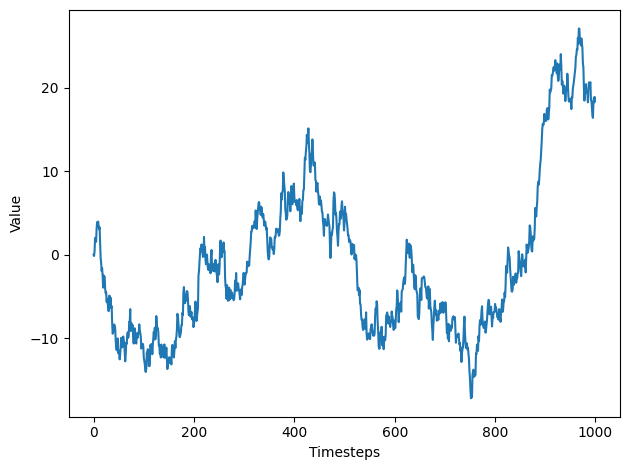

In [4]:
# 도식화
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

* 해석: 처음 400개 시간 단계 동안 양의 추세 후 음의 추세; 끝으로 갈 수록 급격히 증가

* 하지만 실제 데이터에서는 시계열이 확률보행인지 아닌지 식별 필요

# 3.2 확률보행 식별 </br>
**확률보행**: 첫 번째 차분 (1st difference)이 정상적이고 상관관계는 없는 시계열; 절차가 완전히 무작위로 변화

![alt text](Screenshots/3/3.4.png)

## 3.2.1 정상성 Stationary </br>
정의: 시간이 지나도 통계적(평균, 분산, 자기상관관계) 특성이 변하지 않는 시계열
- 평균과 분산이 **상수** 이고 **자기상관관계**가 있으며, 이런 특성들이 시간에 따라 변하지 않는다. 

변환 (transform): 데이터를 수학적 조작을 통해 평균과 분산을 안정화해 정상적 상태로 만드는 것. 
- 차분: 평균 안정화, 추세 및 계절적 효과 제거 또는 줄일 수 있음 </br>

차분: 어떤 시간 단계와 그 다음 시간 단계 사이에 발생하는 일련의 변화를 계산
- $y'_{t} = y_{t} - y_{t-1}$ </br>

시계열에 로그 함수를 적용하면 *분산*을 안정시킬 수 있음.

![alt text](Screenshots/3/3.5.png)

변환 취소/역변환 (untransform/inverse transform): 변환된 시계열을 모델링할 때 모델의 출력을 원래 규모 (scale)로 되돌려야 함 </br>


## 3.2.2 정상성 테스트 </br>
시계열에 변환을 적용한 후 정상성 테스트를 수행하여 다른 변환을 더 적용해야 하는지 아니면 괜찮은지 확인해야 함.
* ADF (Augmented Dickety Fuller) 테스트: 시계열에 단위근 (unit root)이 존재하는 귀무가설 검증; 대체 가설은 단위근이 없으므로 시계열이 정상적이라는 가설
    - 결과값: 음수; 음수의 절대 크기가 클수록 귀무가설을 기각할 가능성이 크다
    - 파이썬에서는 p-값도 같이 나옴 (0.05보다 작으면 귀무가설 기각하여 수열이 정상적이라고 할 수 있음)

$y_t = C + \alpha_{1}y_{t-1} + \epsilon_{t}$ </br>
* $\alpha_1$ 은 unit circle 내에 있는 경우에만 정상적 (==> -1 < $\alpha_1$ < 1 ) 

![alt text](Screenshots/3/3.7.png)

정상적 수열: 시간에 무관하게 일정한 분산 = 시간에 독립적이라는 뜻</br>
비정상적 수열: 시간에 따라 변화하는 분산

시계열이 정상적이라면...
- 자기상관관계가 있는지 확인
    - 확률보행: 첫 번째 차분이 정상적이고 상관관계가 없는 수열
- ADF 테스트: 정상성 여부 확인하지만, 수열에 자기상관관계가 있는지를 확인하려면 자기상관함수를 사용해야 함